# LaboratoryActivity1


### Jade Natasha Ragot

### DS4A

### Dataset

The images used in this activity are in the project repository:
[View the dataset on GitHub](https://github.com/JadeNatasha/Portfolio/tree/main/projects/dataset)

In [1]:
import os
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms
from torchvision import models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [2]:
root = 'dataset'

In [3]:
os.listdir(root)

['0', '1', '2']

In [4]:
data_dict = {'X':[], 'y':[]}

for cls in os.listdir(root):
    cls_path = os.path.join(root, cls)
    for img in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img)
        data_dict['X'].append(img_path)
        data_dict['y'].append(int(cls))

In [5]:
pd.DataFrame(data_dict)

,X,y
0,dataset\0\tr1.jpg,0
1,dataset\0\tr2.jpg,0
2,dataset\0\tr3.jfif,0
3,dataset\1\car1.jfif,1
4,dataset\1\car2.jfif,1
5,dataset\1\car3.jfif,1
6,dataset\2\bike1.jpg,2
7,dataset\2\bike2.jpg,2
8,dataset\2\bike3.jpg,2


### **Wrapping in a `Dataset` class**

In [6]:
class CustomDataset(Dataset):
    def __init__(self, data_dict: dict, transforms=None):
        self.data_dict = data_dict
        self.transforms = transforms

    def __getitem__(self, idx):
        x = cv2.imread(self.data_dict['X'][idx])
        y = self.data_dict['y'][idx]
        if self.transforms:
            x = self.transforms(x)
            y = torch.tensor(y)
        return x, y

    def __len__(self):
        return len(self.data_dict['X'])

### **Define transforms and instantiate the dataset**

In [7]:
trans = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(size=(300, 300)),
    transforms.Normalize(mean=[0, 0, 0], std=[1, 1, 1])
])

cd = CustomDataset(data_dict, trans)

***Sanity Check***

In [8]:
for i in cd:
    print(i[0].shape)

torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])


### ***Initial Demo (single model)***

***Load pretrained MobileNetV2***

***What is MobileNetV2?***

MobileNetV2 is a "lightweight" image-recognition network and is designed to provide high performance while maintaining efficiency built for phones and small devices.

***Source:*** [Mobile Net V2](https://www.geeksforgeeks.org/computer-vision/what-is-mobilenet-v2/#what-is-mobilenet-v2)

In [9]:
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

***Test prediction***

In [10]:
x = cd[1][0].unsqueeze(dim=0)

In [11]:
y_pred = model(x)

In [12]:
torch.argmax(y_pred)

tensor(569)

In [13]:
classes = models.MobileNet_V2_Weights.DEFAULT.meta

In [14]:
classes.keys()

dict_keys(['num_params', 'min_size', 'categories', 'recipe', '_metrics', '_ops', '_file_size', '_docs'])

In [15]:
classes['categories'][569]

'garbage truck'

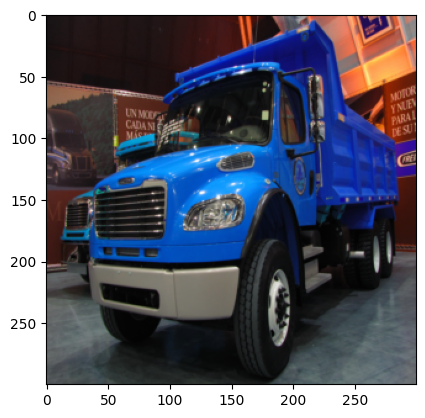

In [16]:
plt.imshow(cd[1][0].permute(1,2,0))

In [17]:
torch.argmax(F.softmax(y_pred))

C:\Users\Jadee\AppData\Local\Temp\ipykernel_12860\153894831.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  torch.argmax(F.softmax(y_pred))


tensor(569)

In [18]:
F.softmax(y_pred)[0]

C:\Users\Jadee\AppData\Local\Temp\ipykernel_12860\3111965656.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  F.softmax(y_pred)[0]


tensor([0.0005, 0.0010, 0.0009, 0.0011, 0.0011, 0.0010, 0.0008, 0.0006, 0.0006,
        0.0009, 0.0007, 0.0006, 0.0007, 0.0007, 0.0010, 0.0006, 0.0005, 0.0011,
        0.0008, 0.0008, 0.0009, 0.0009, 0.0011, 0.0008, 0.0009, 0.0010, 0.0008,
        0.0010, 0.0012, 0.0014, 0.0007, 0.0009, 0.0011, 0.0011, 0.0013, 0.0006,
        0.0008, 0.0007, 0.0009, 0.0007, 0.0009, 0.0009, 0.0010, 0.0006, 0.0006,
        0.0007, 0.0010, 0.0014, 0.0006, 0.0011, 0.0007, 0.0010, 0.0008, 0.0006,
        0.0008, 0.0009, 0.0005, 0.0009, 0.0009, 0.0008, 0.0007, 0.0010, 0.0006,
        0.0007, 0.0008, 0.0007, 0.0010, 0.0012, 0.0008, 0.0014, 0.0013, 0.0014,
        0.0007, 0.0006, 0.0010, 0.0008, 0.0008, 0.0012, 0.0012, 0.0012, 0.0008,
        0.0006, 0.0008, 0.0011, 0.0013, 0.0008, 0.0007, 0.0009, 0.0009, 0.0006,
        0.0005, 0.0006, 0.0006, 0.0006, 0.0006, 0.0007, 0.0007, 0.0006, 0.0011,
        0.0007, 0.0006, 0.0010, 0.0012, 0.0009, 0.0008, 0.0006, 0.0013, 0.0011,
        0.0009, 0.0008, 0.0012, 0.0011, 

***Bucket ImageNet's 1000 classes into my categories***

In [19]:
weights = models.MobileNet_V2_Weights.DEFAULT
categories = weights.meta["categories"]

car_indices = [i for i, name in enumerate(categories) if 'car' in name.lower() or 'cab' in name.lower() or 'limousine' in name.lower()]
truck_indices = [i for i, name in enumerate(categories) if 'truck' in name.lower() or 'bus' in name.lower() or 'trailer' in name.lower()]
bike_indices = [i for i, name in enumerate(categories) if 'bicycle' in name.lower() or 'bike' in name.lower()]

print(f"ImageNet Car Indices: {car_indices}")
print(f"ImageNet Truck Indices: {truck_indices}")
print(f"ImageNet Bike Indices: {bike_indices}")

ImageNet Car Indices: [264, 324, 383, 403, 468, 474, 475, 476, 477, 478, 479, 495, 565, 575, 603, 627, 684, 690, 705, 777, 791, 817, 829, 936, 946, 959]
ImageNet Truck Indices: [138, 375, 569, 654, 779, 864, 867, 874]
ImageNet Bike Indices: [444, 671]


In [20]:
predicted_idx = torch.argmax(y_pred).item()

if predicted_idx in truck_indices:
    print(f"Prediction index {predicted_idx} is a TRUCK (Class 0).")
elif predicted_idx in car_indices:
    print(f"Prediction index {predicted_idx} is a CAR (Class 1).")
elif predicted_idx in bike_indices:
    print(f"Prediction index {predicted_idx} is a BICYCLE (Class 2).")
else:
    print(f"Prediction index {predicted_idx} is something else entirely.")

Prediction index 569 is a TRUCK (Class 0).


### **Evaluation and Comparison**

***Adding a `Data Loader`***

In [21]:
loader = DataLoader(cd, batch_size=4, shuffle=False)

***Reusable Evaluation Function***

Writing the logic once, then running it 5 times (once per model) instead of copy-pasting the same block of code 5 times with tiny edits.

In [22]:
def evaluate_model(model, loader, car_idx, truck_idx, bike_idx):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            outputs = model(x_batch)
            preds = torch.argmax(outputs, dim=1)
            for p, true_label in zip(preds, y_batch):
                p = p.item()
                if p in truck_idx:
                    pred_label = 0
                elif p in car_idx:
                    pred_label = 1
                elif p in bike_idx:
                    pred_label = 2
                else:
                    pred_label = -1
                y_pred.append(pred_label)
                y_true.append(true_label.item())
    return y_true, y_pred

***Loading 4 more models***

In [23]:
model_list = {
    "MobileNetV2": models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT),
    "ResNet18": models.resnet18(weights=models.ResNet18_Weights.DEFAULT),
    "ResNet50": models.resnet50(weights=models.ResNet50_Weights.DEFAULT),
    "VGG16": models.vgg16(weights=models.VGG16_Weights.DEFAULT),
    "EfficientNet_B0": models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT),
}

***Evaluation and Computing Metrics***

In [24]:
results = []
for name, model in model_list.items():
    y_true, y_pred = evaluate_model(model, loader, car_indices, truck_indices, bike_indices)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='macro', zero_division=0),
        "Recall": recall_score(y_true, y_pred, average='macro', zero_division=0),
        "F1": f1_score(y_true, y_pred, average='macro', zero_division=0),
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1
0,MobileNetV2,1.000000,1.00,1.000000,1.000
1,ResNet18,0.333333,0.50,0.250000,0.325
2,ResNet50,0.666667,0.75,0.500000,0.575
3,VGG16,0.444444,0.75,0.333333,0.450
4,EfficientNet_B0,0.777778,0.75,0.583333,0.625


***Comparison Visualization***

C:\Users\Jadee\AppData\Local\Temp\ipykernel_12860\2054074493.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlGnBu')


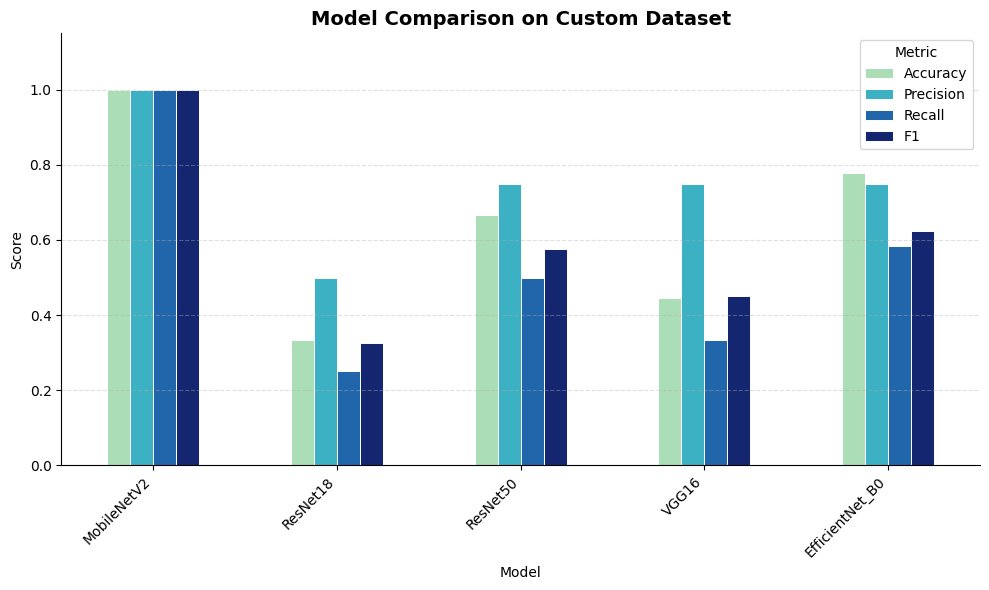

In [25]:
cmap = cm.get_cmap('YlGnBu')
bar_colors = [cmap(x) for x in np.linspace(0.3, 0.95, 4)]  # skip the very palest end for readability

ax = results_df.set_index("Model")[["Accuracy","Precision","Recall","F1"]].plot(
    kind='bar', figsize=(10,6), color=bar_colors, edgecolor='white', linewidth=0.7
)
plt.title("Model Comparison on Custom Dataset", fontsize=14, fontweight='bold')
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.15)
plt.legend(title="Metric")
plt.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

### **Deeper Investigation**

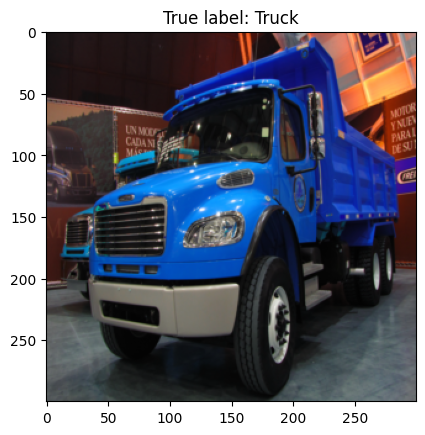

MobileNetV2: predicted 'Truck' (ImageNet index 569 → 'garbage truck')
ResNet18: predicted 'Truck' (ImageNet index 867 → 'trailer truck')


ResNet50: predicted 'Truck' (ImageNet index 569 → 'garbage truck')


VGG16: predicted 'Truck' (ImageNet index 569 → 'garbage truck')
EfficientNet_B0: predicted 'Truck' (ImageNet index 569 → 'garbage truck')


In [26]:
test_idx = 1
x = cd[test_idx][0].unsqueeze(dim=0)
true_label = ["Truck", "Car", "Bicycle"][cd[test_idx][1]]

plt.imshow(cd[test_idx][0].permute(1,2,0))
plt.title(f"True label: {true_label}")
plt.show()

for name, model in model_list.items():
    model.eval()
    with torch.no_grad():
        y_pred = model(x)
    predicted_idx = torch.argmax(y_pred).item()

    if predicted_idx in truck_indices:
        pred_label = "Truck"
    elif predicted_idx in car_indices:
        pred_label = "Car"
    elif predicted_idx in bike_indices:
        pred_label = "Bicycle"
    else:
        pred_label = "Something else"

    print(f"{name}: predicted '{pred_label}' (ImageNet index {predicted_idx} → '{classes['categories'][predicted_idx]}')")

***Prediction Check***

In [27]:
label_names = ["Truck", "Car", "Bicycle"]

detailed_results = []
for name, model in model_list.items():
    y_true, y_pred = evaluate_model(model, loader, car_indices, truck_indices, bike_indices)
    for idx, (true_lbl, pred_lbl) in enumerate(zip(y_true, y_pred)):
        detailed_results.append({
            "Model": name,
            "Image Index": idx,
            "Predicted Label": label_names[pred_lbl] if pred_lbl != -1 else "Unmatched"
        })

detailed_df = pd.DataFrame(detailed_results)
pivot = detailed_df.pivot(index="Image Index", columns="Model", values="Predicted Label")
pivot.insert(0, "True Label", [label_names[y] for y in cd.data_dict['y']])
pivot

Model,True Label,EfficientNet_B0,MobileNetV2,ResNet18,ResNet50,VGG16
Image Index,,,,,,
0,Truck,Truck,Truck,Truck,Truck,Truck
1,Truck,Truck,Truck,Truck,Truck,Truck
2,Truck,Truck,Truck,Unmatched,Truck,Unmatched
3,Car,Car,Car,Unmatched,Car,Unmatched
4,Car,Car,Car,Unmatched,Unmatched,Unmatched
5,Car,Car,Car,Unmatched,Unmatched,Car
6,Bicycle,Unmatched,Bicycle,Unmatched,Unmatched,Unmatched
7,Bicycle,Unmatched,Bicycle,Unmatched,Bicycle,Unmatched
8,Bicycle,Bicycle,Bicycle,Bicycle,Bicycle,Bicycle


***Per Category Difficulty***

In [28]:
model_cols = [col for col in pivot.columns if col != "True Label"]

# Mark correct/incorrect per model per image
correctness = pivot[model_cols].eq(pivot["True Label"], axis=0)
correctness["True Label"] = pivot["True Label"]

# Group by class, compute % correct per model
per_class_accuracy = correctness.groupby("True Label")[model_cols].mean()
per_class_accuracy

Model,EfficientNet_B0,MobileNetV2,ResNet18,ResNet50,VGG16
True Label,,,,,
Bicycle,0.333333,1.0,0.333333,0.666667,0.333333
Car,1.000000,1.0,0.000000,0.333333,0.333333
Truck,1.000000,1.0,0.666667,1.000000,0.666667


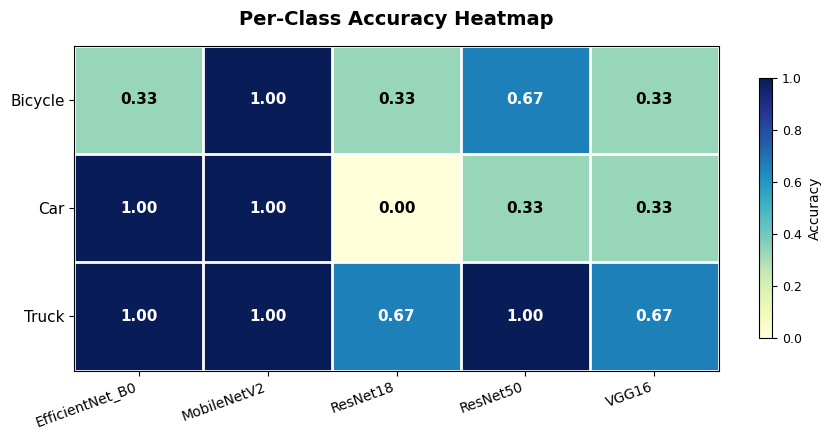

In [29]:
fig, ax = plt.subplots(figsize=(9,4.5))

im = ax.imshow(per_class_accuracy.values, cmap='YlGnBu', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(len(model_cols)))
ax.set_xticklabels(model_cols, rotation=20, ha='right', fontsize=10)
ax.set_yticks(range(len(per_class_accuracy.index)))
ax.set_yticklabels(per_class_accuracy.index, fontsize=11)

ax.set_xticks(np.arange(-0.5, len(model_cols), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(per_class_accuracy.index), 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)

for i in range(len(per_class_accuracy.index)):
    for j in range(len(model_cols)):
        value = per_class_accuracy.values[i, j]
        text_color = 'white' if value > 0.6 else 'black'
        ax.text(j, i, f"{value:.2f}", ha='center', va='center', color=text_color, fontsize=11, fontweight='bold')

ax.set_title("Per-Class Accuracy Heatmap", fontsize=14, fontweight='bold', pad=15)
cbar = fig.colorbar(im, label="Accuracy", shrink=0.8)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('per_class_accuracy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

*Bicycle images proved challenging for several models*

### **Insights and Reflections**

***What are the models?***

**MobileNetV2**: The MobileNet V2 architecture is designed to provide high performance while maintaining efficiency for mobile and embedded applications it also provides accurate predictions with minimal computational resources.

**ResNet18**: A small-to-medium sized network from a completely different architecture family (residual connections/skip connections), useful as a "different design philosophy, similar size" comparison point to MobileNetV2.

**ResNet50**: Same family as ResNet18, but deeper/bigger. Having both lets us compare the same architecture, but in different size. 

**VGG16**: This is a much older (2014), much bigger, much simpler architecture (just stacked convolution layers, no residual connections or fancy tricks). Useful as a big but old-fashioned baseline against the more modern, efficient options.

**EfficientNet_B0**: And this is a newer architecture explicitly designed to be highly accurate and efficient at the same time, representing more recent research than any of the others.

>> *Comparing these five models that spans different depths, architecture families, and release years — allows us to examine how model complexity and design philosophy affect performance on the same custom dataset.*

***Overall Results Summary***

>> *Given our custom dataset, among the five models tested, MobileNetV2 achieved a perfect 1.00 across all four metrics, followed by EfficientNet_B0, which matched ResNet50 and VGG16's precision and scored higher on accuracy, recall, and F1. ResNet50, VGG16, and ResNet18 trailed behind, in that order, with ResNet18 performing weakest overall. Interestingly, this ranking doesn't line up neatly with release date — MobileNetV2 and EfficientNet_B0 are both fairly recent, yet outperformed ResNet50 and ResNet18, while VGG16, the oldest model here (2014), still scored higher than ResNet18. This suggests that a model's age or how "modern" its architecture is doesn't reliably predict performance on a small, specific custom dataset like this — factors such as how closely our images resemble the model's original training data, and how well our keyword-based category matching happened to align with each model's top predictions, likely played a bigger role than architecture generation alone.*

>> *Despite being one of the more lightweight, mobile-optimized architectures, MobileNetV2 performed best on our dataset — suggesting that for a small, simple 3-class task like this, a compact model isn't necessarily a disadvantage. On the other hand, VGG16 and ResNet18, despite different design philosophies, both underperformed, indicating that a model's success on our specific images may depend more on how closely our photos resemble ImageNet's training examples than on model size or depth alone.*